# JobStreet Indonesia - Job Market Analysis

**Author:** Hansen Lawrence  
**Date:** January 2026  
**Data Source:** JobStreet Indonesia (Web Scraping)

---

## Objective
Analyze job market trends for Data Analyst, Data Scientist, and Data Engineer roles in Indonesia.

## Key Questions
1. Which companies are hiring the most?
2. What are the top locations for data roles?
3. What is the salary range for data positions?
4. What job titles are most in-demand?

## 1. Setup & Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Colors
COLORS = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c', '#34495e', '#e91e63']

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Data

In [2]:
# Load CSV file
import glob

# Find the latest CSV file
csv_files = glob.glob('jobstreet_jobs_*.csv')
if csv_files:
    latest_file = max(csv_files)
    print(f'Loading: {latest_file}')
    df = pd.read_csv(latest_file)
else:
    print('No CSV file found!')

print(f'\nTotal records: {len(df)}')
df.head()

Loading: jobstreet_jobs_20260119_222421.csv

Total records: 95


,title,company,location,salary,date,url,scraped_at
0,Data Analyst,PT Main Games Indonesia (Jakarta),Jakarta Selatan,NaN,NaN,https://id.jobstreet.com/id/job/89775936?type=...,2026-01-19 22:21:38
1,Junior Business Analyst,PT Perangkat Lunak Indonesia,Jakarta Pusat,Rp 5.500.000 – Rp 7.000.000 per month,NaN,https://id.jobstreet.com/id/job/89762700?type=...,2026-01-19 22:21:38
2,Data Analyst Section Head (Marunda),"PT SMART,Tbk",Jakarta Utara,NaN,NaN,https://id.jobstreet.com/id/job/89780614?type=...,2026-01-19 22:21:38
3,Data Analyst,PT Nusantara Sakti Group (JAKARTA),Jakarta Barat,Rp 7.000.000 – Rp 10.000.000 per month,NaN,https://id.jobstreet.com/id/job/89406341?type=...,2026-01-19 22:21:38
4,Data Analyst,PT Eigerindo Multi Produk Industri,Kabupaten Bandung,NaN,NaN,https://id.jobstreet.com/id/job/89312663?type=...,2026-01-19 22:21:38


## 3. Data Overview

In [3]:
# Basic info
print('='*50)
print('DATA OVERVIEW')
print('='*50)
print(f'Total Jobs: {len(df)}')
print(f'Unique Companies: {df["company"].nunique()}')
print(f'Unique Locations: {df["location"].nunique()}')
print(f'Jobs with Salary: {df[df["salary"] != "N/A"]["salary"].count()}')
print('='*50)

DATA OVERVIEW
Total Jobs: 95
Unique Companies: 86
Unique Locations: 29
Jobs with Salary: 27


In [4]:
# Data types and missing values
print('\nColumn Info:')
print('-'*40)
for col in df.columns:
    non_na = df[df[col] != 'N/A'][col].count()
    pct = (non_na / len(df)) * 100
    print(f'{col}: {non_na} ({pct:.1f}%)')


Column Info:
----------------------------------------
title: 95 (100.0%)
company: 95 (100.0%)
location: 95 (100.0%)
salary: 27 (28.4%)
date: 0 (0.0%)
url: 95 (100.0%)
scraped_at: 95 (100.0%)


## 4. Top Companies Hiring

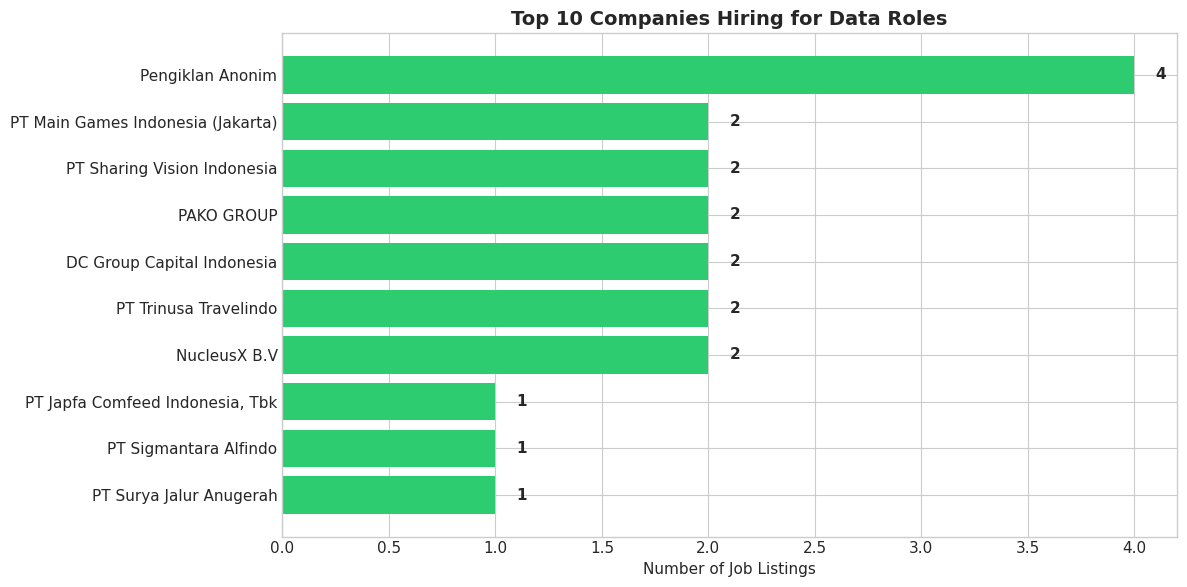


Top 10 Companies:
1. Pengiklan Anonim: 4 jobs
2. PT Main Games Indonesia (Jakarta): 2 jobs
3. PT Sharing Vision Indonesia: 2 jobs
4. PAKO GROUP: 2 jobs
5. DC Group Capital Indonesia: 2 jobs
6. PT Trinusa Travelindo: 2 jobs
7. NucleusX B.V: 2 jobs
8. PT Japfa Comfeed Indonesia, Tbk: 1 jobs
9. PT Sigmantara Alfindo: 1 jobs
10. PT Surya Jalur Anugerah: 1 jobs


In [5]:
# Top 10 companies
company_counts = df[df['company'] != 'N/A']['company'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(company_counts.index[::-1], company_counts.values[::-1], color=COLORS[0])

# Add value labels
for bar, val in zip(bars, company_counts.values[::-1]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold')

ax.set_xlabel('Number of Job Listings')
ax.set_title('Top 10 Companies Hiring for Data Roles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_top_companies.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 Companies:')
for i, (company, count) in enumerate(company_counts.items(), 1):
    print(f'{i}. {company}: {count} jobs')

## 5. Job Distribution by Location

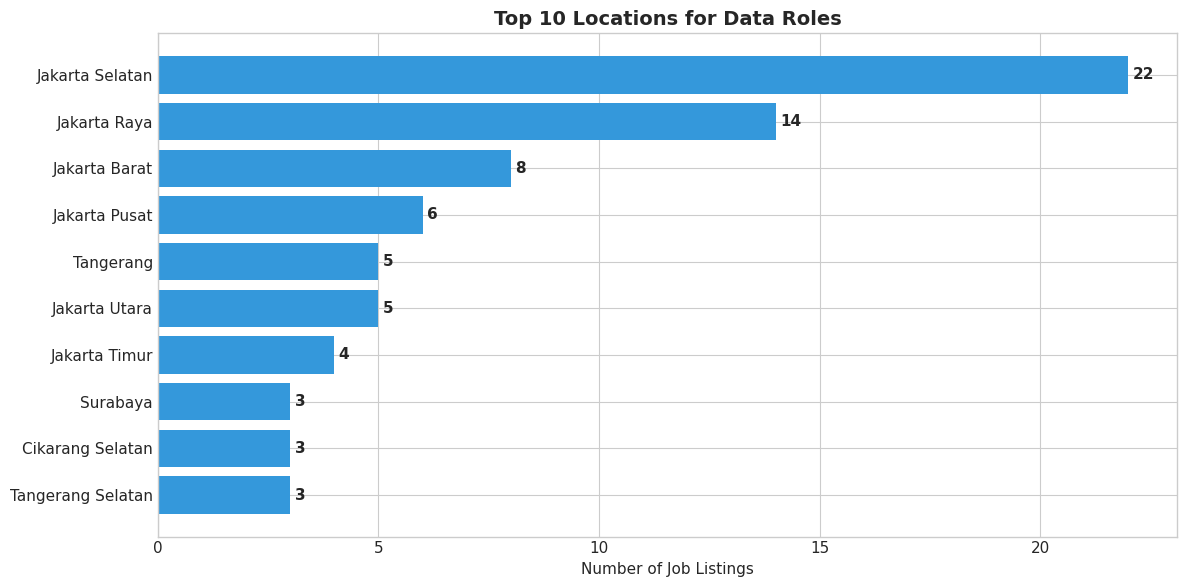


Top 10 Locations:
1. Jakarta Selatan: 22 jobs
2. Jakarta Raya: 14 jobs
3. Jakarta Barat: 8 jobs
4. Jakarta Pusat: 6 jobs
5. Tangerang: 5 jobs
6. Jakarta Utara: 5 jobs
7. Jakarta Timur: 4 jobs
8. Surabaya: 3 jobs
9. Cikarang Selatan: 3 jobs
10. Tangerang Selatan: 3 jobs


In [6]:
# Top 10 locations
location_counts = df[df['location'] != 'N/A']['location'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(location_counts.index[::-1], location_counts.values[::-1], color=COLORS[1])

# Add value labels
for bar, val in zip(bars, location_counts.values[::-1]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold')

ax.set_xlabel('Number of Job Listings')
ax.set_title('Top 10 Locations for Data Roles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_top_locations.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 Locations:')
for i, (loc, count) in enumerate(location_counts.items(), 1):
    print(f'{i}. {loc}: {count} jobs')

## 6. Salary Analysis

In [7]:
# Extract salary data
df_salary = df[df['salary'] != 'N/A'].copy()

def extract_salary(salary_str):
    """Extract min and max salary from string"""
    if pd.isna(salary_str) or salary_str == 'N/A':
        return None, None
    
    # Find all numbers in the string
    numbers = re.findall(r'[\d\.]+', salary_str.replace('.', ''))
    numbers = [float(n) for n in numbers if float(n) > 1000]  # Filter valid salaries
    
    if len(numbers) >= 2:
        return min(numbers), max(numbers)
    elif len(numbers) == 1:
        return numbers[0], numbers[0]
    return None, None

# Apply extraction
df_salary['salary_min'], df_salary['salary_max'] = zip(*df_salary['salary'].apply(extract_salary))
df_salary = df_salary.dropna(subset=['salary_min'])

# Convert to millions
df_salary['salary_min_m'] = df_salary['salary_min'] / 1_000_000
df_salary['salary_max_m'] = df_salary['salary_max'] / 1_000_000
df_salary['salary_avg_m'] = (df_salary['salary_min_m'] + df_salary['salary_max_m']) / 2

print(f'Jobs with valid salary data: {len(df_salary)}')
df_salary[['title', 'company', 'salary', 'salary_min_m', 'salary_max_m']].head(10)

Jobs with valid salary data: 25


,title,company,salary,salary_min_m,salary_max_m
1,Junior Business Analyst,PT Perangkat Lunak Indonesia,Rp 5.500.000 – Rp 7.000.000 per month,5.5,7.0
3,Data Analyst,PT Nusantara Sakti Group (JAKARTA),Rp 7.000.000 – Rp 10.000.000 per month,7.0,10.0
6,Marketing Data Analyst,PT Dipo Star Finance,Rp 6.000.000 – Rp 8.000.000 per month,6.0,8.0
11,Data Analyst,PT Adi Sarana Armada (Assa Rent),Rp 6.000.000 – Rp 8.000.000 per month,6.0,8.0
15,Admin Data Analyst,PT. Sumber Prima Anugrah Abadi,Rp 5.000.000 – Rp 5.400.000 per month,5.0,5.4
18,Market Data Analyst Jakarta,PT Galva Galindra Multi Cipta,Rp 7.000.000 – Rp 10.000.000 per month,7.0,10.0
21,Data & Business Analyst (E-Commerce),JINISO.ID,Rp 7.000.000 – Rp 10.000.000 per month,7.0,10.0
29,DATA ANALYST,PT Temprina Media Grafika,Rp 6.000.000 – Rp 7.500.000 per month,6.0,7.5
30,Finance Reporting & Data Analyst Supervisor,PT Bahana Inovasi Adikarya,Rp15.000.000 – Rp20.000.000 per month,15.0,20.0
48,Data Support Spv - Consumer Good,Pengiklan Anonim,Rp 6.000.000 – Rp 9.000.000 per month,6.0,9.0


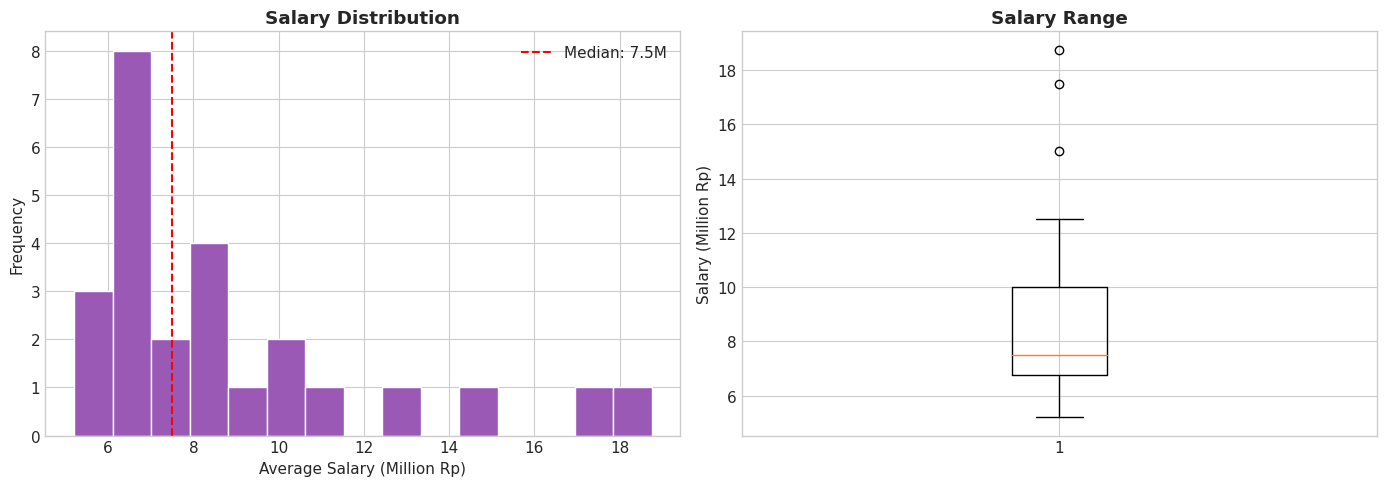


Salary Statistics (in Million Rp):
----------------------------------------
Minimum: Rp 5.0 jt
Maximum: Rp 22.5 jt
Average: Rp 9.0 jt
Median:  Rp 7.5 jt


In [8]:
# Salary distribution
if len(df_salary) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(df_salary['salary_avg_m'], bins=15, color=COLORS[2], edgecolor='white')
    axes[0].set_xlabel('Average Salary (Million Rp)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Salary Distribution', fontweight='bold')
    axes[0].axvline(df_salary['salary_avg_m'].median(), color='red', linestyle='--', label=f'Median: {df_salary["salary_avg_m"].median():.1f}M')
    axes[0].legend()
    
    # Box plot
    axes[1].boxplot(df_salary['salary_avg_m'], vert=True)
    axes[1].set_ylabel('Salary (Million Rp)')
    axes[1].set_title('Salary Range', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('chart_salary_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Statistics
    print('\nSalary Statistics (in Million Rp):')
    print('-'*40)
    print(f'Minimum: Rp {df_salary["salary_min_m"].min():.1f} jt')
    print(f'Maximum: Rp {df_salary["salary_max_m"].max():.1f} jt')
    print(f'Average: Rp {df_salary["salary_avg_m"].mean():.1f} jt')
    print(f'Median:  Rp {df_salary["salary_avg_m"].median():.1f} jt')
else:
    print('No valid salary data to analyze')

## 7. Job Title Analysis

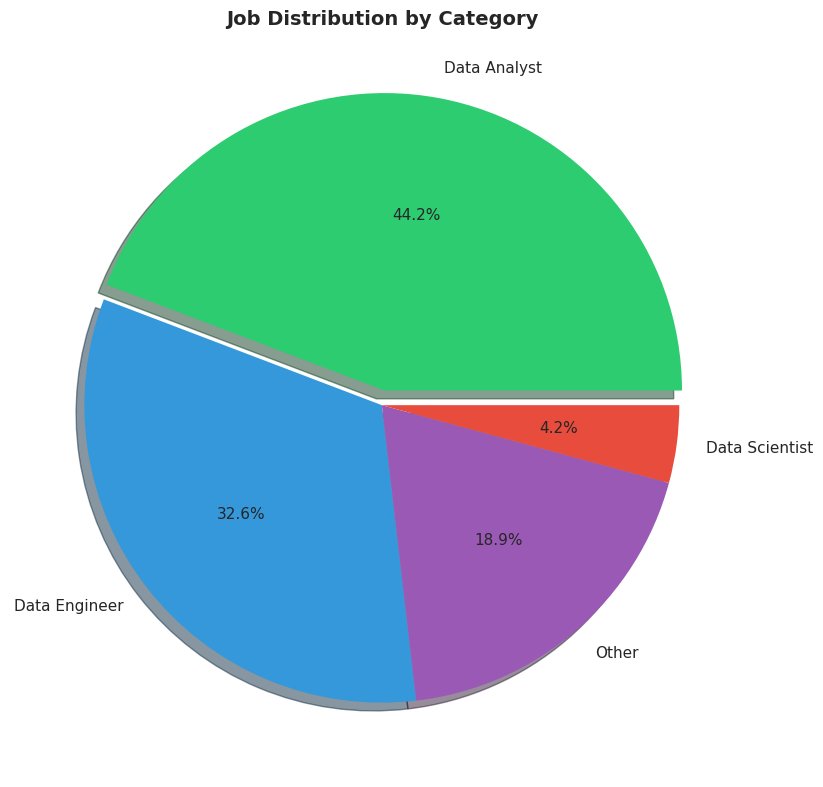


Job Categories:
Data Analyst: 42 (44.2%)
Data Engineer: 31 (32.6%)
Other: 18 (18.9%)
Data Scientist: 4 (4.2%)


In [9]:
# Categorize job titles
def categorize_job(title):
    title_lower = title.lower()
    if 'scientist' in title_lower:
        return 'Data Scientist'
    elif 'engineer' in title_lower:
        return 'Data Engineer'
    elif 'analyst' in title_lower:
        return 'Data Analyst'
    elif 'business' in title_lower:
        return 'Business Analyst'
    else:
        return 'Other'

df['job_category'] = df['title'].apply(categorize_job)
category_counts = df['job_category'].value_counts()

# Pie chart
fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    category_counts.values, 
    labels=category_counts.index,
    autopct='%1.1f%%',
    colors=COLORS[:len(category_counts)],
    explode=[0.05 if i == 0 else 0 for i in range(len(category_counts))],
    shadow=True
)
ax.set_title('Job Distribution by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_job_categories.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nJob Categories:')
for cat, count in category_counts.items():
    pct = (count / len(df)) * 100
    print(f'{cat}: {count} ({pct:.1f}%)')

## 8. Summary Dashboard

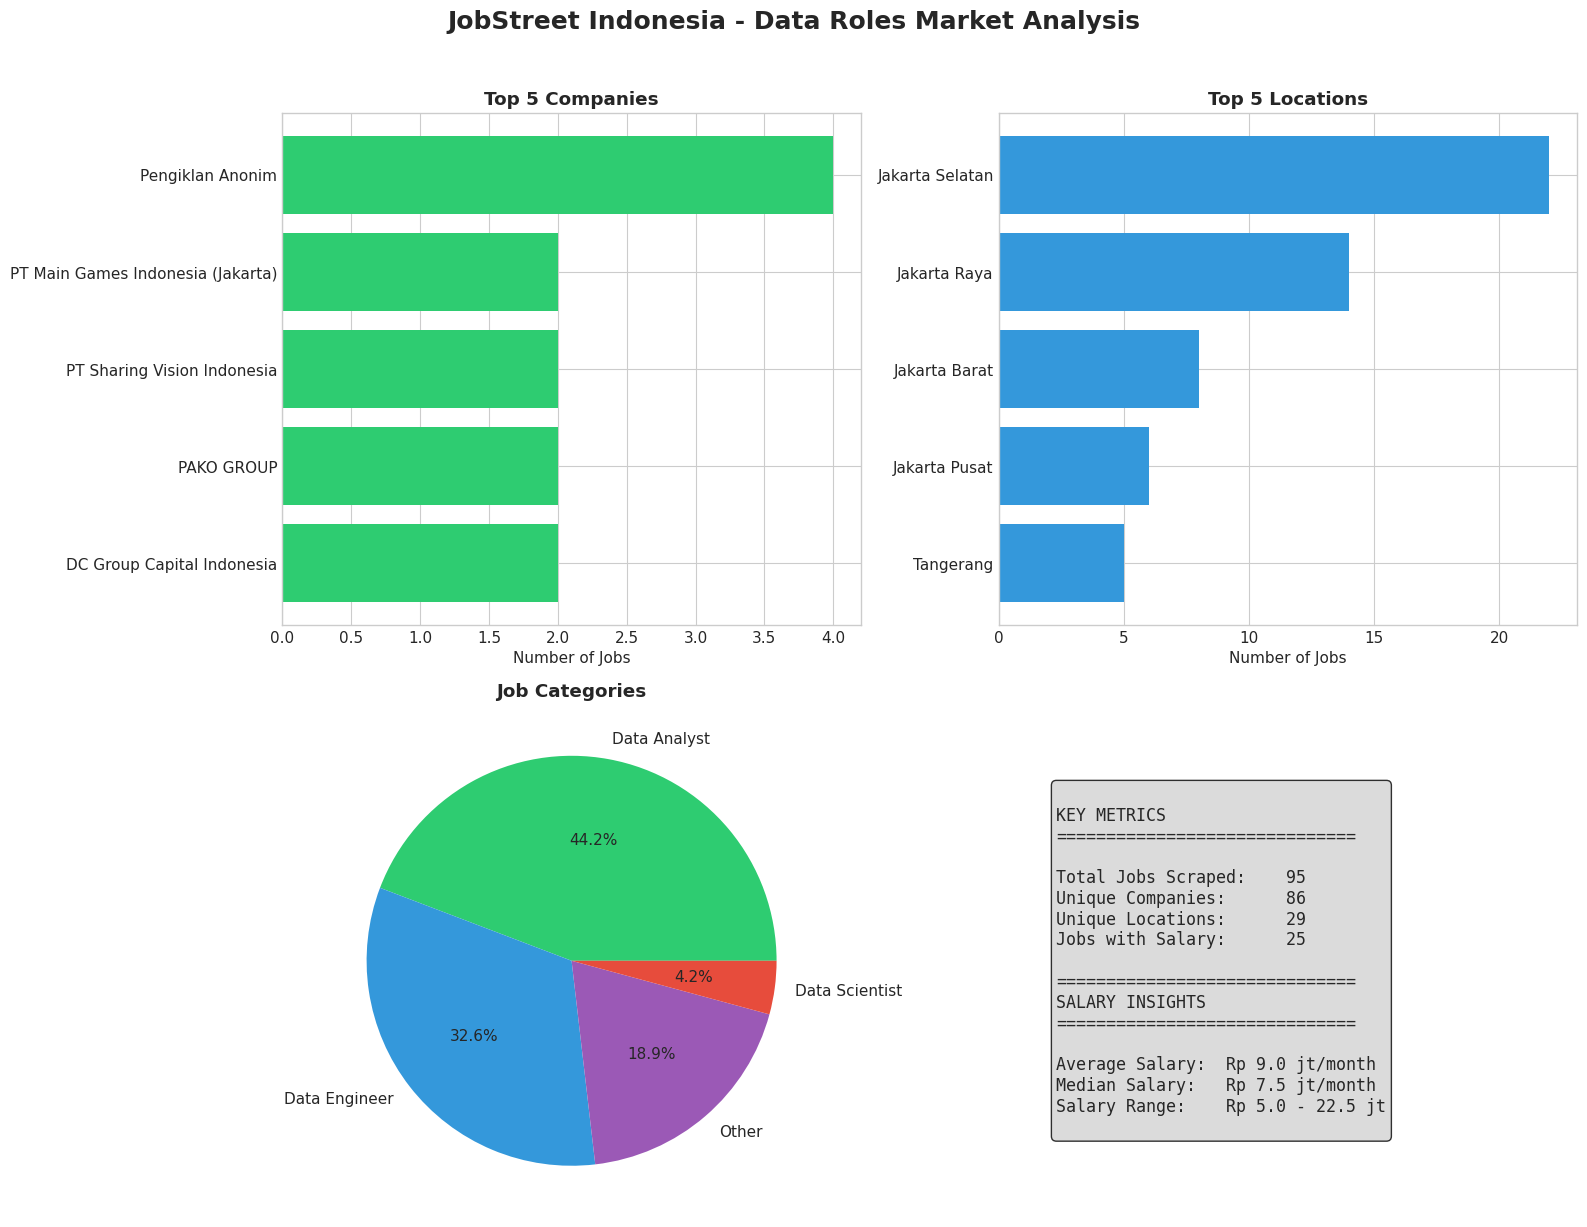


Dashboard saved to: dashboard_summary.png


In [10]:
# Create summary dashboard
fig = plt.figure(figsize=(16, 12))

# Title
fig.suptitle('JobStreet Indonesia - Data Roles Market Analysis', fontsize=18, fontweight='bold', y=1.02)

# 1. Top Companies (top left)
ax1 = fig.add_subplot(2, 2, 1)
top_companies = df[df['company'] != 'N/A']['company'].value_counts().head(5)
ax1.barh(top_companies.index[::-1], top_companies.values[::-1], color=COLORS[0])
ax1.set_title('Top 5 Companies', fontweight='bold')
ax1.set_xlabel('Number of Jobs')

# 2. Top Locations (top right)
ax2 = fig.add_subplot(2, 2, 2)
top_locations = df[df['location'] != 'N/A']['location'].value_counts().head(5)
ax2.barh(top_locations.index[::-1], top_locations.values[::-1], color=COLORS[1])
ax2.set_title('Top 5 Locations', fontweight='bold')
ax2.set_xlabel('Number of Jobs')

# 3. Job Categories (bottom left)
ax3 = fig.add_subplot(2, 2, 3)
ax3.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', colors=COLORS[:len(category_counts)])
ax3.set_title('Job Categories', fontweight='bold')

# 4. Key Metrics (bottom right)
ax4 = fig.add_subplot(2, 2, 4)
ax4.axis('off')
metrics_text = f"""
KEY METRICS
{'='*30}

Total Jobs Scraped:    {len(df)}
Unique Companies:      {df['company'].nunique()}
Unique Locations:      {df['location'].nunique()}
Jobs with Salary:      {len(df_salary)}

{'='*30}
SALARY INSIGHTS
{'='*30}

Average Salary:  Rp {df_salary['salary_avg_m'].mean():.1f} jt/month
Median Salary:   Rp {df_salary['salary_avg_m'].median():.1f} jt/month
Salary Range:    Rp {df_salary['salary_min_m'].min():.1f} - {df_salary['salary_max_m'].max():.1f} jt
""" if len(df_salary) > 0 else f"""
KEY METRICS
{'='*30}

Total Jobs Scraped:    {len(df)}
Unique Companies:      {df['company'].nunique()}
Unique Locations:      {df['location'].nunique()}
"""
ax4.text(0.1, 0.5, metrics_text, transform=ax4.transAxes, fontsize=12, verticalalignment='center', 
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.savefig('dashboard_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDashboard saved to: dashboard_summary.png')

## 9. Conclusions

### Key Findings:

1. **Jakarta dominates** the data job market with the highest number of openings
2. **Data Analyst** is the most common entry-level position
3. **Salary range** for data roles is approximately Rp 5-10 million/month for entry-level
4. Various industries are hiring - from tech startups to established corporations

### Recommendations for Job Seekers:

- Focus on Jakarta area for maximum opportunities
- Build skills in Python, SQL, and data visualization
- Consider both startups and established companies
- Negotiate salary based on market data

---

**Analysis by Hansen Lawrence**  
*Data Engineer | Data Analyst*